# SER Analysis — Starter (example) Notebook

Each week you need to create separate notebook and do some analysis. You create additional notebooks in this `notebooks/` folder for each stage of your analysis (e.g., EDA, classification, clustering, etc.).

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Audio
import librosa
import librosa.display

# MiniLearn — your from-scratch library
import minilearn
from minilearn.model_selection import train_test_split
from minilearn.preprocessing import StandardScaler
from minilearn.classifiers import LogisticRegression, KNN, GaussianNaiveBayes, DecisionTreeClassifier
from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

ModuleNotFoundError: No module named 'minilearn.classifiers'

In [17]:
# load processed data
metadata = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_metadata.csv")
features = pd.read_csv("/home/westley/Documents/classes/spring_2026/machine_learning/Project_CSE432-532/SER_Project/processed_data/ravdess_features.csv")

# load dataframes
df = metadata.merge(features, on="filename", how="inner")
numeric_df = df.select_dtypes(include=["number"])

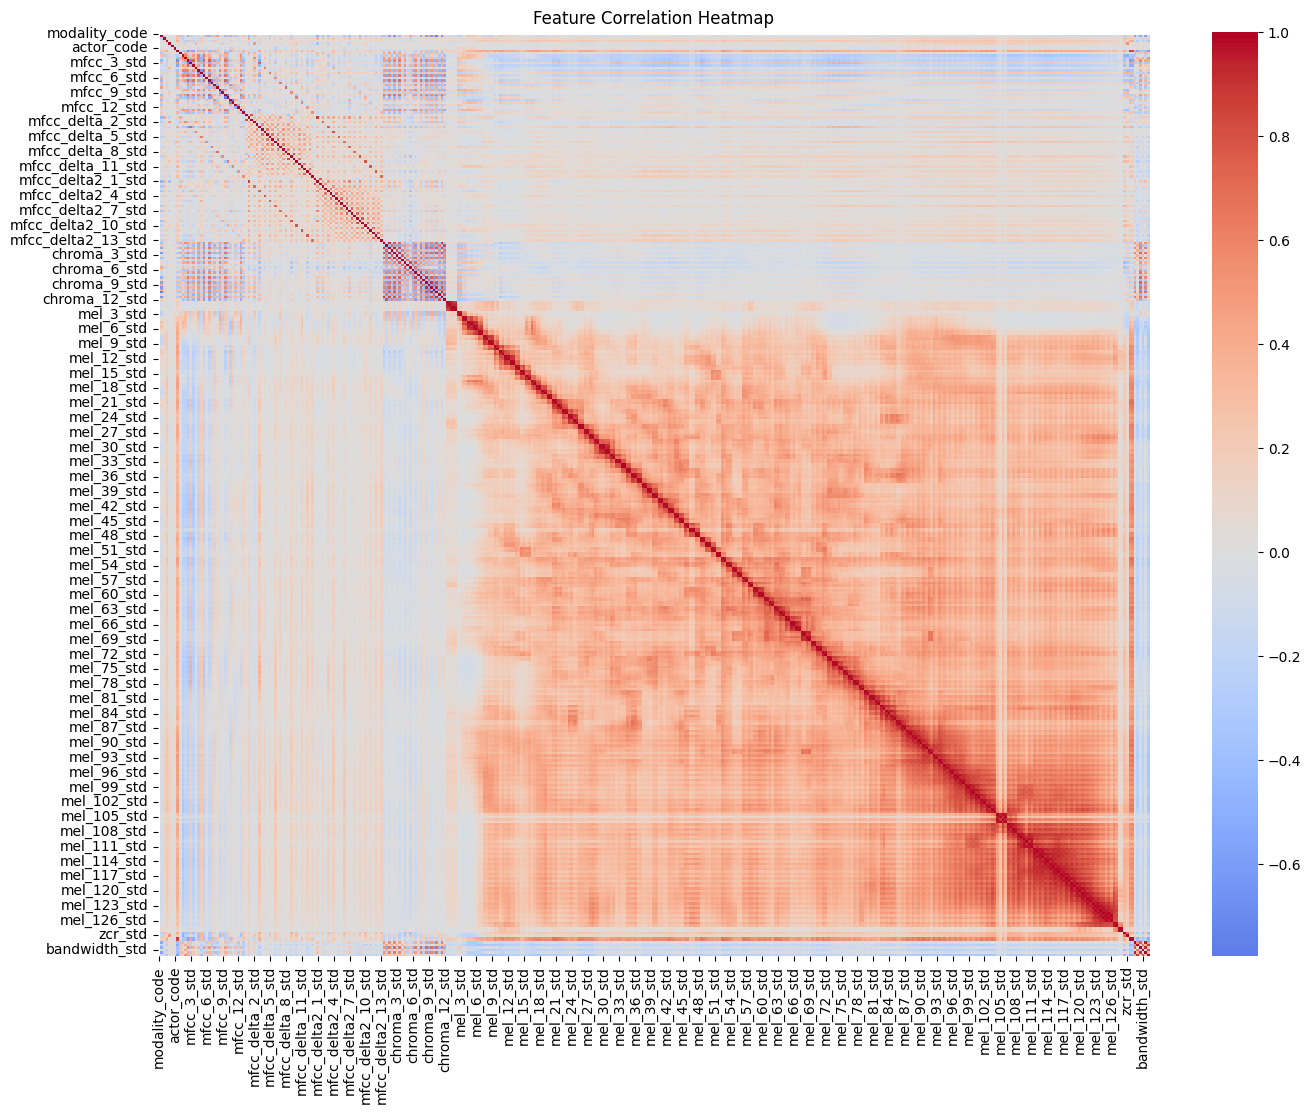

mel_128_mean       mel_128_std           0.994484
mel_125_mean       mel_126_mean          0.992422
mel_34_mean        mel_34_std            0.990307
mel_47_mean        mel_47_std            0.988488
mel_125_std        mel_126_std           0.988125
                                           ...   
mel_9_mean         mel_10_std            0.779570
mel_23_std         mel_24_std            0.778992
mel_87_mean        mel_89_std            0.778742
mel_95_mean        mel_99_mean           0.778671
mfcc_delta_12_std  mfcc_delta2_12_std    0.778476
Length: 1000, dtype: float64


In [18]:
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

corr_matrix = numeric_df.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

top_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .head(1000)
)

print(top_pairs)

There is high correlation between mel means and stds, as well as correlation between closely numbered mel values. The same can be said with chroma means and stds. It's hard to tell what other correlations exist because of the quantity of mel features.

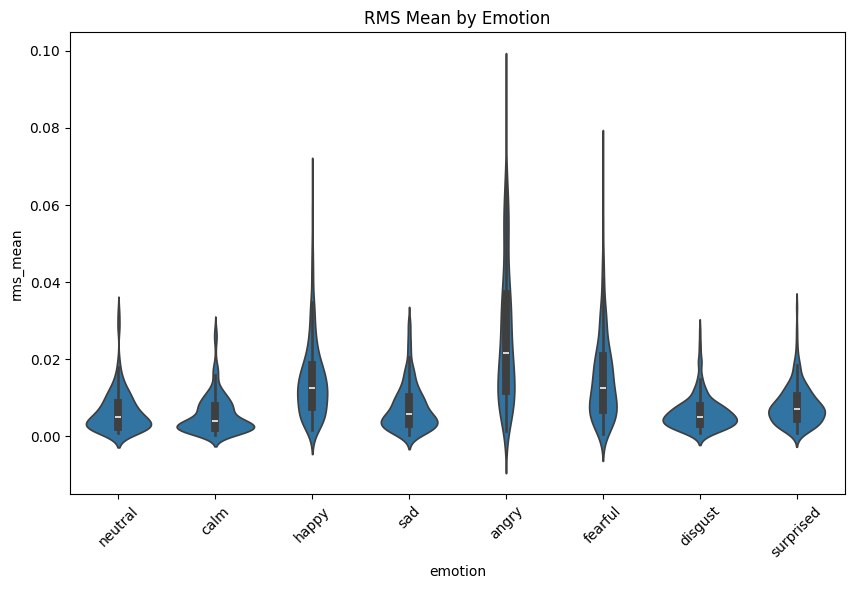

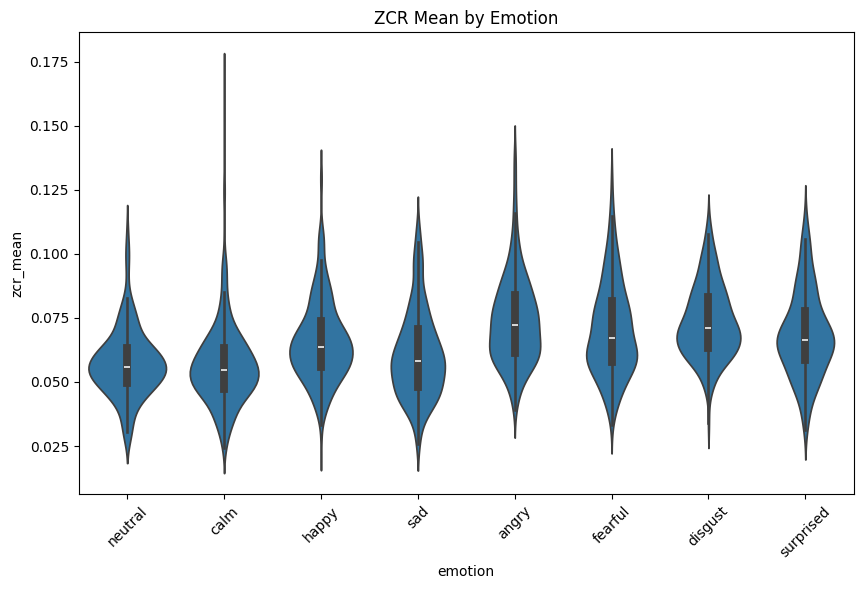

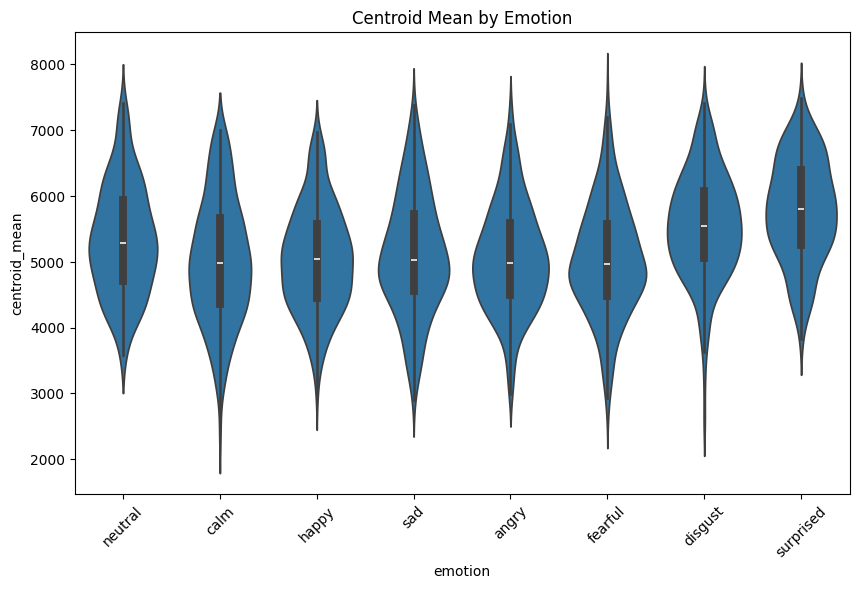

In [19]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="emotion", y="rms_mean")
plt.title("RMS Mean by Emotion")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="emotion", y="zcr_mean")
plt.title("ZCR Mean by Emotion")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="emotion", y="centroid_mean")
plt.title("Centroid Mean by Emotion")
plt.xticks(rotation=45)
plt.show()

In [20]:
df.groupby("emotion")[["rms_mean", "zcr_mean", "centroid_mean"]].mean()

,rms_mean,zcr_mean,centroid_mean
emotion,,,
angry,0.026199,0.073973,5061.024069
calm,0.005696,0.056520,5022.000141
disgust,0.006165,0.073492,5553.440437
fearful,0.015218,0.070437,5026.912565
happy,0.014723,0.065909,5044.078861
neutral,0.006472,0.057340,5334.386507
sad,0.007538,0.060726,5106.891183
surprised,0.008045,0.068609,5780.533526


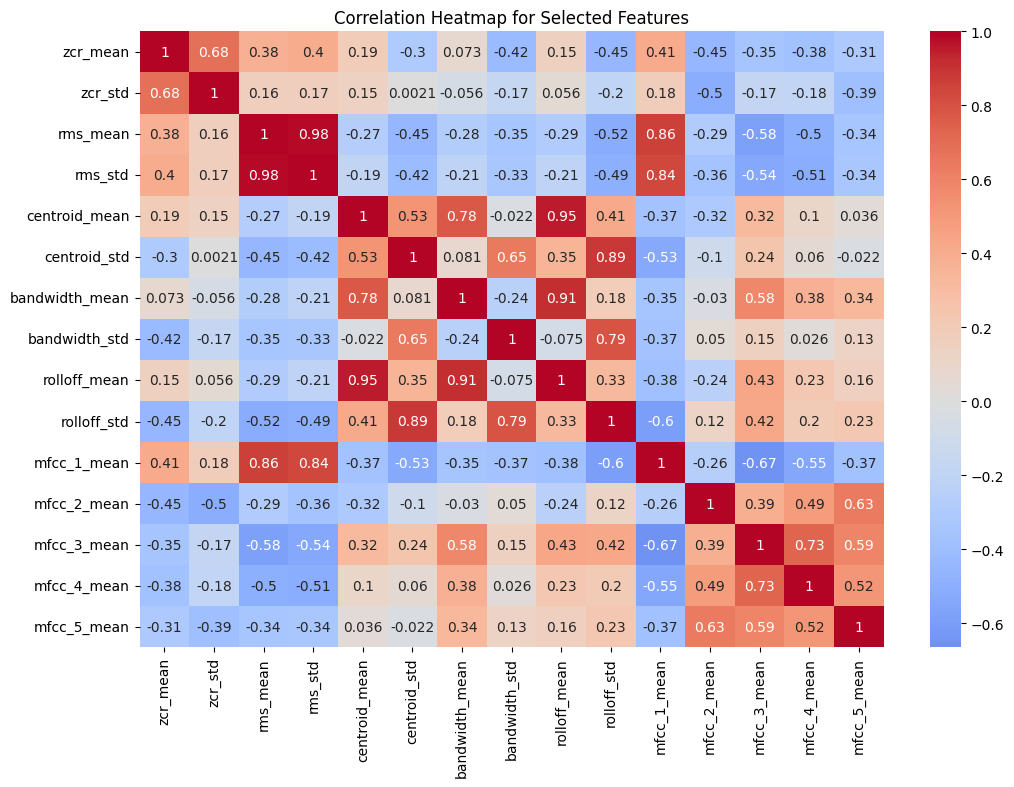

rms_mean        rms_std           0.980671
centroid_mean   rolloff_mean      0.952076
bandwidth_mean  rolloff_mean      0.911663
centroid_std    rolloff_std       0.888374
rms_mean        mfcc_1_mean       0.861276
rms_std         mfcc_1_mean       0.836122
bandwidth_std   rolloff_std       0.789441
centroid_mean   bandwidth_mean    0.776484
mfcc_3_mean     mfcc_4_mean       0.730588
zcr_mean        zcr_std           0.678418
mfcc_1_mean     mfcc_3_mean       0.665269
centroid_std    bandwidth_std     0.647033
mfcc_2_mean     mfcc_5_mean       0.630224
rolloff_std     mfcc_1_mean       0.596683
mfcc_3_mean     mfcc_5_mean       0.592019
rms_mean        mfcc_3_mean       0.583897
bandwidth_mean  mfcc_3_mean       0.582182
mfcc_1_mean     mfcc_4_mean       0.550367
rms_std         mfcc_3_mean       0.541495
centroid_std    mfcc_1_mean       0.534085
dtype: float64


In [21]:
selected = [
    "zcr_mean", "zcr_std",
    "rms_mean", "rms_std",
    "centroid_mean", "centroid_std",
    "bandwidth_mean", "bandwidth_std",
    "rolloff_mean", "rolloff_std",
    "mfcc_1_mean", "mfcc_2_mean", "mfcc_3_mean", "mfcc_4_mean", "mfcc_5_mean"
]

corr_small = df[selected].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_small, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Selected Features")
plt.show()

corr_small_matrix = corr_small.abs()

upper = corr_small_matrix.where(
    np.triu(np.ones(corr_small_matrix.shape), k=1).astype(bool)
)

top_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .head(20)
)

print(top_pairs)

Here we can see a high coorelation betwen centroid and rolloff, bandwidth and rolloff, and rms and mfcc.

In [26]:
# Time to standardize the data

drop_cols = [
    "filename", "filepath",
    "modality_code", "vocal_channel_code", "emotion_code",
    "intensity_code", "statement_code", "repetition_code", "actor_code",
    "modality", "vocal_channel", "emotion", "intensity",
    "statement", "repetition", "actor_gender"
]

X = df.drop(columns=drop_cols)
y = df["emotion"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

np.isnan(X_train_scaled).sum()
np.isinf(X_train_scaled).sum()
X_train_scaled.mean(axis=0)[:5]
X_train_scaled.std(axis=0)[:5]

array([1., 1., 1., 1., 1.])

In [ ]:
# Baseline model

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(confusion_matrix(y_test, y_pred))

AttributeError: module 'minilearn' has no attribute 'LogisticRegression'